In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading the dataset
df = pd.read_csv("student_performance_with_grades.csv")

In [4]:
df.head() 

,Student_ID,Gender,Age,Study_Hours,Attendance_Percentage,Assignment_Score,Midterm_Score,Final_Exam_Score,Extracurricular,Performance_Score,Grade
0,STU0001,Male,16,6.8,77.1,65,62.4,85.3,No,74.4,B
1,STU0002,Female,16,3.2,77.7,80.7,103.5,79.7,Yes,87.0,A
2,STU0003,Male,18,5.3,85.9,68.4,85.7,93.3,No,86.0,A
3,STU0004,Male,21,5.9,77.8,82.6,67.5,84.1,No,78.8,B
4,STU0005,Male,17,2.8,84.9,77.4,37.0,71.9,No,62.5,C


The first five records were examined to understand the structure and contents of the dataset.

In [5]:
df.shape

(315, 11)

 above code helps in knowing data dimensions(size) :
The dataset contains 315 rows and 11 columns. This represents the initial size of the dataset before any cleaning or preprocessing operations.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315 entries, 0 to 314
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             315 non-null    object 
 1   Gender                 315 non-null    object 
 2   Age                    315 non-null    int64  
 3   Study_Hours            298 non-null    object 
 4   Attendance_Percentage  299 non-null    float64
 5   Assignment_Score       299 non-null    object 
 6   Midterm_Score          315 non-null    float64
 7   Final_Exam_Score       309 non-null    float64
 8   Extracurricular        315 non-null    object 
 9   Performance_Score      315 non-null    float64
 10  Grade                  315 non-null    object 
dtypes: float64(4), int64(1), object(6)
memory usage: 27.2+ KB


The .info() function was used to inspect column names, non-null counts, and data types.

In [ ]:
df.describe().T # for statistical summary of the dataset

,count,mean,std,min,25%,50%,75%,max
Age,315.0,18.949206,2.032528,16.0,17.00,19.0,21.00,22.0
Attendance_Percentage,299.0,81.499666,13.415529,5.0,75.80,82.2,89.05,108.3
Midterm_Score,315.0,72.768254,14.174232,35.7,62.65,72.6,81.40,108.4
Final_Exam_Score,309.0,75.269256,15.043081,30.2,65.70,75.0,85.30,121.9
Performance_Score,315.0,74.741905,8.757389,52.3,68.70,74.3,80.80,97.2


The descriptive statistics provide an overview of the numerical features including count, mean, standard deviation, minimum values, maximum values, and quartiles.these statistics help identify unusual values, missing observations.

In [8]:
df.dtypes

Student_ID                object
Gender                    object
Age                        int64
Study_Hours               object
Attendance_Percentage    float64
Assignment_Score          object
Midterm_Score            float64
Final_Exam_Score         float64
Extracurricular           object
Performance_Score        float64
Grade                     object
dtype: object

This indicates the presence of rogue text values or invalid entries within these columns. These datatype inconsistencies must be corrected before performing statistical analysis.

In [9]:
#proof
print(df["Study_Hours"].unique())

['6.8' '3.2' '5.3' '5.9' '2.8' '4.4' '-1.3' '2.7' '4' '2.3' nan '1.9'
 '3.7' '4.7' '7.1' '6.6' '4.5' '4.9' '3.4' '4.6' '3.8' '5.7' '7.4' '8.3'
 '1' '4.2' '5.6' '5' '4.1' '3.6' '6' '5.1' '3.3' '6.1' '3' '3.5' '5.8'
 '5.5' '6.5' '3.9' '4.3' '18' '2.9' 'Unknown' '6.3' '5.2' '2' '7.2' '5.4'
 '3.1' '6.2' '8.4' '4.8' '0.7' '7.9' '2.1' '7.8' '1.4' '6.9' '6.7' '1.6'
 '2.6' '2.5' '1.7' '7.3' '8.2' '7.7' '7' '6.4' '2.4' '0.8' '2.2' '8' '0.4'
 '1.8' '7.5' '10' '1.5' '1.3' '0.1']


In [10]:
print(df["Assignment_Score"].unique())

['65' '80.7' '68.4' '82.6' '77.4' nan '93.6' '96.6' '67.6' '70.3' '78.4'
 '79' '82.9' '99.1' '72.9' '65.4' '58.4' '66.2' '74.6' '96.5' '68.8'
 '77.7' '74.8' '89.3' '105.3' '68.6' '69.1' '87.5' '83.2' '97.2' '82'
 '70.7' '82.1' '84.8' 'Absent' '87.8' '89' '91.6' '82.8' '73' '76.8'
 '89.5' '65.2' '79.4' '75.3' '90.3' '77.3' '75.6' '58.7' '84' '82.7' '101'
 '71.3' '77.6' '78' '73.9' '78.3' '82.3' '77.2' '69.6' '87.9' '62.7'
 '76.6' '66.6' '56.7' '68.3' '79.5' '93.8' '74.2' '97.6' '57.6' '48.6'
 '80.3' '69' '83.5' '77.9' '68.2' '59.6' '85.5' '73.8' '62.2' '66.7'
 '74.5' '72.1' '79.2' '92.3' '74' '88.4' '79.1' '80.5' '81.8' '80.4'
 '90.9' '66.9' '57.8' '76.5' '66.8' '85.1' '67.2' '45.9' '56' '84.1'
 '84.4' '63.4' '74.4' '75' '61.1' '93' '77.5' '50.5' '72' '63' '71.6'
 '68.1' '81.9' '91.8' '86.1' '83.4' '79.7' '85.7' '87.6' '90.8' '99.9'
 '95.8' '69.2' '71.2' '80.1' '81.3' '74.7' '100.7' '95.7' '80.2' '75.5'
 '82.4' '71.9' '55' '79.8' '93.9' '60.3' '57.4' '95.2' '69.5' '85.6'
 '56.1' '92.7' 

## Phase1 summary
The dataset structure was examined using `.shape`, `.info()`, and `.describe().T`.
Most columns have appropriate data types. However, `Study_Hours` and `Assignment_Score` are stored as object types even though they should contain numerical values.
Upon inspection, invalid entries such as **"Unknown"** and **"Absent"** were found in these columns, causing datatype inconsistencies. These issues will be corrected during the data cleaning phase.

In [12]:
df.duplicated().sum() 

np.int64(15)

A duplicate check was performed before data cleaning. The dataset contained 15 duplicate records, which could lead to inaccurate statistics if left untreated.

In [13]:
df = df.drop_duplicates()

This helps remove the duplicates


In [14]:
df.duplicated().sum()

np.int64(0)

This helped us verify that there are no duplicate records in the dataset.

In [15]:
df.isnull().sum()

Student_ID                0
Gender                    0
Age                       0
Study_Hours              15
Attendance_Percentage    15
Assignment_Score         15
Midterm_Score             0
Final_Exam_Score          4
Extracurricular           0
Performance_Score         0
Grade                     0
dtype: int64

The dataset contains missing values in multiple columns. Study_Hours, Attendance_Percentage, Assignment_Score, and Final_Exam_Score contain null values that require treatment before analysis and model building.

In [17]:
df["Study_Hours"] = pd.to_numeric(df["Study_Hours"], errors="coerce")
df["Assignment_Score"] = pd.to_numeric(df["Assignment_Score"], errors="coerce") # type coercion is performed

Type coercion was performed on the Study_Hours and Assignment_Score columns using `pd.to_numeric(errors='coerce')`.
Invalid text values such as "Unknown" and "Absent" were converted into missing values (NaN), allowing these columns to be stored as numerical datatypes for further analysis.

In [18]:
df.dtypes

Student_ID                object
Gender                    object
Age                        int64
Study_Hours              float64
Attendance_Percentage    float64
Assignment_Score         float64
Midterm_Score            float64
Final_Exam_Score         float64
Extracurricular           object
Performance_Score        float64
Grade                     object
dtype: object

we verify that the data types of the columns "Study_Hours" and "Assignment_Score" have been successfully converted to numeric types.

In [19]:
df.isnull().sum()

Student_ID                0
Gender                    0
Age                       0
Study_Hours              19
Attendance_Percentage    15
Assignment_Score         19
Midterm_Score             0
Final_Exam_Score          4
Extracurricular           0
Performance_Score         0
Grade                     0
dtype: int64



The number of missing values increased after type coercion because invalid text entries such as "Unknown" and "Absent" were converted into NaN values. This allows the columns to be treated as numerical data for further analysis.

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,300.0,18.950000,2.021829,16.0,17.000,19.00,21.00,22.0
Study_Hours,281.0,4.657651,2.368835,-1.3,3.200,4.50,5.70,18.0
Attendance_Percentage,285.0,81.244211,13.426761,5.0,75.800,81.80,88.80,108.3
Assignment_Score,281.0,76.903203,11.840929,40.2,69.100,77.40,84.40,105.3
Midterm_Score,300.0,72.814333,14.175570,35.7,62.675,72.75,81.35,108.4
Final_Exam_Score,296.0,75.347635,15.024053,30.2,65.925,75.05,85.55,121.9
Performance_Score,300.0,74.827000,8.819386,52.3,68.700,74.35,80.95,97.2


In [22]:
df["Study_Hours"] = df["Study_Hours"].fillna(df["Study_Hours"].median())

df["Attendance_Percentage"] = df["Attendance_Percentage"].fillna(df["Attendance_Percentage"].median())

df["Assignment_Score"] = df["Assignment_Score"].fillna(df["Assignment_Score"].median())

df["Final_Exam_Score"] = df["Final_Exam_Score"].fillna(df["Final_Exam_Score"].median())



Missing values were replaced using the median of each numerical column. The median was chosen because it is less affected by extreme values and provides a more reliable estimate for missing entries than the mean.

In [23]:
df.isnull().sum()

Student_ID               0
Gender                   0
Age                      0
Study_Hours              0
Attendance_Percentage    0
Assignment_Score         0
Midterm_Score            0
Final_Exam_Score         0
Extracurricular          0
Performance_Score        0
Grade                    0
dtype: int64

In [24]:
df.to_csv("cleaned_dataset.csv", index=False)

## Phase 2 Summary
In this phase, duplicate records were removed, incorrect data types were corrected, missing values were identified and handled using the median, and the cleaned dataset was saved for further analysis.

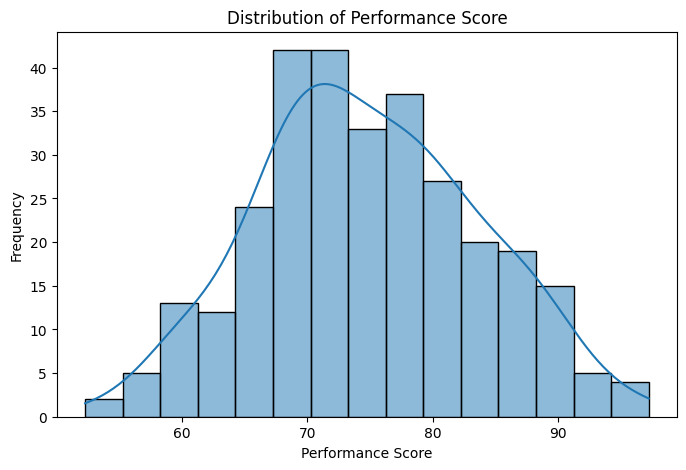

In [25]:
#Histogram (Univariate Analysis)
plt.figure(figsize=(8,5))
sns.histplot(df["Performance_Score"], bins=15, kde=True)

plt.title("Distribution of Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Frequency")

plt.show()

In [26]:
df["Performance_Score"].skew()

np.float64(0.10390626823574371)

OBSERVATION : 
The Performance_Score distribution is approximately normal with a slight positive skewness (0.10). Most students scored between 65 and 85, indicating a balanced distribution of academic performance.

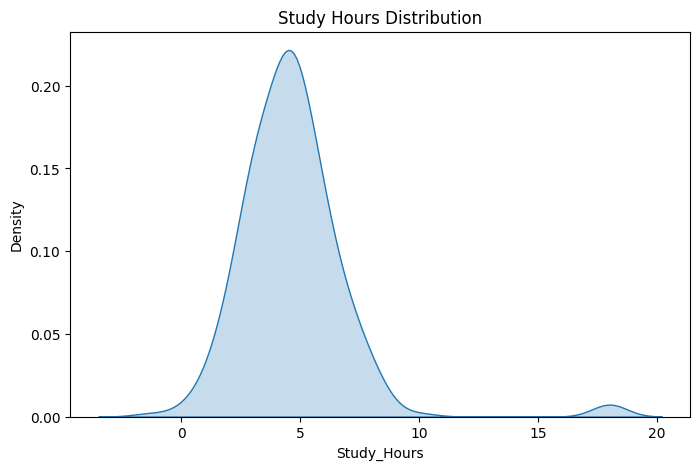

In [27]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["Study_Hours"], fill=True)

plt.title("Study Hours Distribution")

plt.show()

In [28]:
df["Study_Hours"].skew()

np.float64(2.555723846323197)

Observation : 
The Study_Hours distribution is positively skewed with a skewness value of 2.56. Most students study between 3 and 7 hours, while a few students have exceptionally high study hours, creating a long right tail in the distribution.

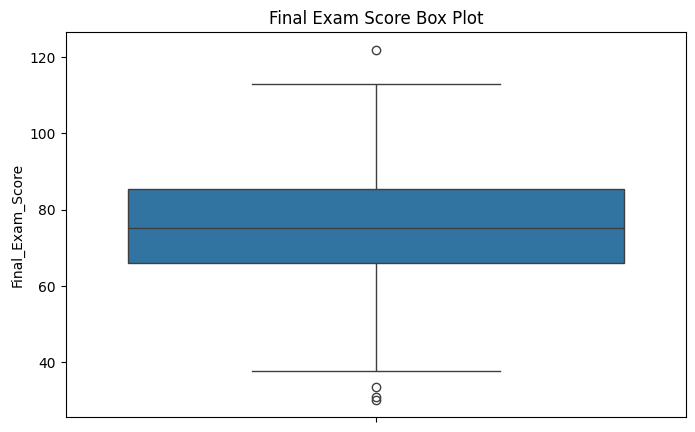

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["Final_Exam_Score"])

plt.title("Final Exam Score Box Plot")

plt.show()



The box plot shows the distribution of Final_Exam_Score and highlights several outliers. A few students have unusually low scores, while one student has an exceptionally high score. These extreme values may require further investigation or treatment before building a machine learning model.

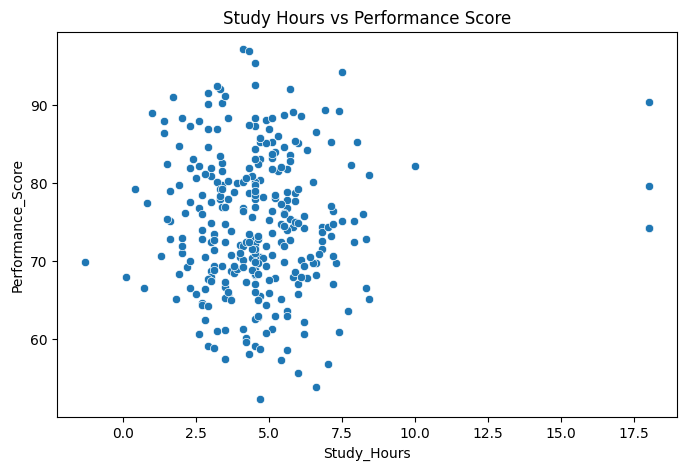

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Study_Hours",
    y="Performance_Score",
    data=df
)
plt.title("Study Hours vs Performance Score")

plt.show()



obsevation : The scatter plot shows a weak positive relationship between Study_Hours and Performance_Score. Most students study between 2 and 8 hours, with performance scores concentrated between 65 and 85. A few students with unusually high study hours appear as potential outliers.

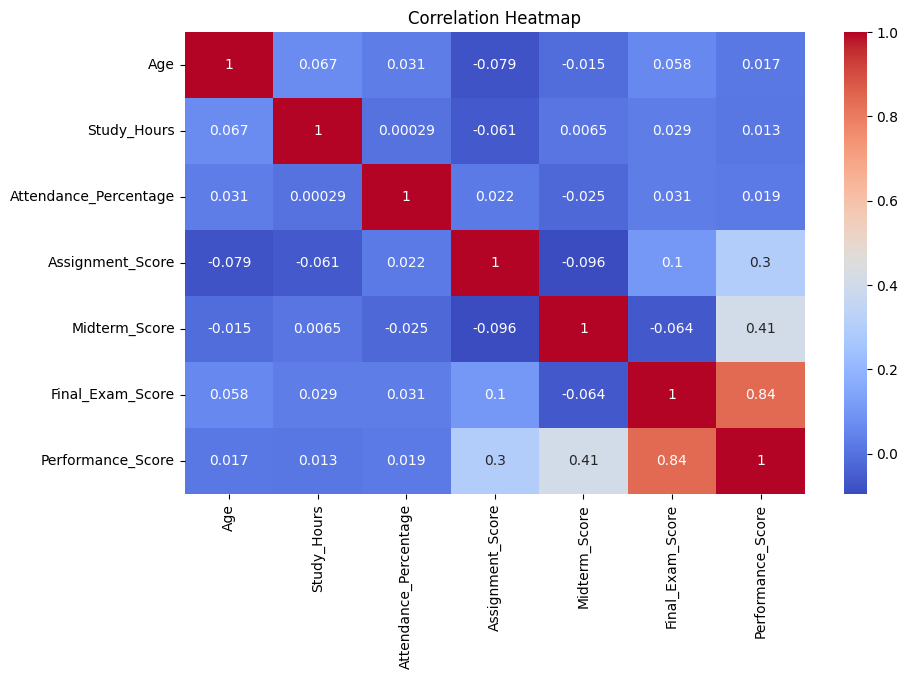

In [35]:
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=["int64","float64"]).corr()
sns.heatmap(corr,annot=True,
cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

Observation: The correlation heatmap shows the relationships between numerical features. Final_Exam_Score has a strong positive correlation with Performance_Score (0.84), indicating that higher final exam marks are strongly associated with better overall performance. Midterm_Score also shows a moderate positive correlation (0.41) with Performance_Score, while most other features have weak correlations.

## Key Insights from the Analysis
- Final exam scores have the strongest influence on overall student performance.
- Midterm scores show a moderate relationship with performance.
- Study hours alone do not strongly predict academic success.
- Data cleaning was essential to remove duplicates, correct datatypes, and handle missing values.
- The cleaned dataset is now suitable for further statistical analysis and machine learning applications.

In [ ]:
corr = df.select_dtypes(include=["int64", "float64"]).corr()

corr["Performance_Score"].sort_values(ascending=False)
#This will show which features are most strongly correlated with Performance_Score.

Performance_Score        1.000000
Final_Exam_Score         0.843554
Midterm_Score            0.407170
Assignment_Score         0.301105
Attendance_Percentage    0.019409
Age                      0.017069
Study_Hours              0.013126
Name: Performance_Score, dtype: float64

In [ ]:
Q1 = df["Final_Exam_Score"].quantile(0.25)
Q3 = df["Final_Exam_Score"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[
    (df["Final_Exam_Score"] < lower_bound) |
    (df["Final_Exam_Score"] > upper_bound)
]
print("Number of Outliers:", len(outliers))

Number of Outliers: 4


In [38]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
Student_ID               0
Gender                   0
Age                      0
Study_Hours              0
Attendance_Percentage    0
Assignment_Score         0
Midterm_Score            0
Final_Exam_Score         0
Extracurricular          0
Performance_Score        0
Grade                    0
dtype: int64

Duplicate Rows:
0

Data Types:
Student_ID                object
Gender                    object
Age                        int64
Study_Hours              float64
Attendance_Percentage    float64
Assignment_Score         float64
Midterm_Score            float64
Final_Exam_Score         float64
Extracurricular           object
Performance_Score        float64
Grade                     object
dtype: object


# Insights for ML Modeling

### 1. Which specific features exhibit high correlation metrics and run the risk of causing multi-collinearity or data redundancy?

Final_Exam_Score shows a strong positive correlation (0.84) with Performance_Score, indicating that these features are closely related. Using highly correlated features together may introduce redundancy and should be considered carefully during feature selection.

### 2. Which data columns contain severe statistical outliers that will require capping, clipping, or mathematical transformations prior to training?

The Final_Exam_Score column contains several outliers, including unusually low and high values identified through box plot analysis. These extreme values may require capping or transformation before training a machine learning model.

### 3. What definitive structural changes did you execute to guarantee that an ML algorithm's .fit() function will run seamlessly without crashing on bad inputs?

The following data cleaning steps were performed:

- Removed 15 duplicate records.
- Corrected the data types of Study_Hours and Assignment_Score using type coercion.
- Converted invalid entries such as "Unknown" and "Absent" into missing values (NaN).
- Handled missing values using median imputation.
- Verified that no missing values remained in the final dataset.
- Saved the cleaned dataset as `cleaned_dataset.csv`.

These changes ensured that the dataset is clean, consistent, and ready for machine learning applications.